In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
data = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [4]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.

In [6]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5

    return W1, b1, W2, b2


def ReLU(Z):
    return np.maximum(0, Z)


def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    return np.exp(Z) / np.sum(np.exp(Z), axis=0, keepdims=True)


def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)

    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2


def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T

    return one_hot_Y


def deriv_ReLU(Z):
    return Z > 0


def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)

    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2


def update_params(W1, b1, W2, b2,
                  dW1, db1, dW2, db2, alpha):

    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1

    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2

    return W1, b1, W2, b2

In [7]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(
            Z1, A1, Z2, A2, W1, W2, X, Y
        )
        W1, b1, W2, b2 = update_params(
            W1, b1, W2, b2,
            dW1, db1, dW2, db2, alpha
        )

        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print("Accuracy: ", get_accuracy(predictions, Y))

    return W1, b1, W2, b2

In [8]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.1)

Iteration:  0
[2 2 2 ... 2 2 2] [4 0 8 ... 7 0 7]
Accuracy:  0.07965853658536586
Iteration:  10
[8 4 2 ... 8 3 2] [4 0 8 ... 7 0 7]
Accuracy:  0.16195121951219513
Iteration:  20
[8 4 2 ... 8 3 8] [4 0 8 ... 7 0 7]
Accuracy:  0.2405609756097561
Iteration:  30
[8 4 8 ... 8 0 8] [4 0 8 ... 7 0 7]
Accuracy:  0.29521951219512194
Iteration:  40
[8 4 8 ... 8 0 8] [4 0 8 ... 7 0 7]
Accuracy:  0.3533414634146341
Iteration:  50
[8 4 8 ... 8 0 8] [4 0 8 ... 7 0 7]
Accuracy:  0.415390243902439
Iteration:  60
[8 0 7 ... 9 0 8] [4 0 8 ... 7 0 7]
Accuracy:  0.4709024390243902
Iteration:  70
[8 0 7 ... 9 0 9] [4 0 8 ... 7 0 7]
Accuracy:  0.5148292682926829
Iteration:  80
[8 0 7 ... 9 0 9] [4 0 8 ... 7 0 7]
Accuracy:  0.5581951219512196
Iteration:  90
[9 0 7 ... 7 0 7] [4 0 8 ... 7 0 7]
Accuracy:  0.5979024390243902
Iteration:  100
[9 0 7 ... 7 0 7] [4 0 8 ... 7 0 7]
Accuracy:  0.6308780487804878
Iteration:  110
[9 0 7 ... 7 0 7] [4 0 8 ... 7 0 7]
Accuracy:  0.655
Iteration:  120
[9 0 7 ... 7 0 7] [4 0

In [9]:
Z1_dev, A1_dev, Z2_dev, A2_dev = forward_prop(W1, b1, W2, b2, X_dev)

dev_predictions = get_predictions(A2_dev)

dev_accuracy = np.sum(dev_predictions == Y_dev) / Y_dev.size

print(f"Dev accuracy: {dev_accuracy:.2%}")

Dev accuracy: 86.20%


In [10]:
digit_results = []

for digit in range(10):
    digit_indexes = Y_dev == digit

    correct = np.sum(
        dev_predictions[digit_indexes] == Y_dev[digit_indexes]
    )
    total = np.sum(digit_indexes)

    accuracy = correct / total
    digit_results.append((digit, accuracy, total))

digit_results.sort(key=lambda result: result[1])

for digit, accuracy, total in digit_results:
    print(f"Digit {digit}: {accuracy:.2%} ({total} images)")

Digit 5: 73.33% (90 images)
Digit 8: 77.38% (84 images)
Digit 9: 80.00% (115 images)
Digit 4: 84.09% (88 images)
Digit 7: 86.00% (100 images)
Digit 3: 87.27% (110 images)
Digit 2: 87.64% (89 images)
Digit 6: 91.18% (102 images)
Digit 0: 91.51% (106 images)
Digit 1: 99.14% (116 images)


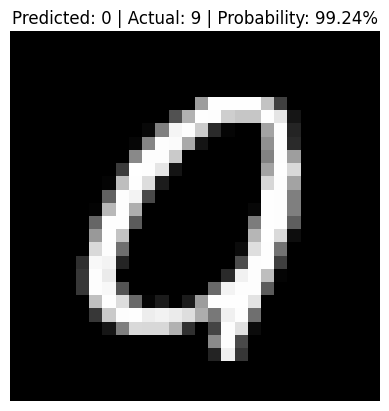

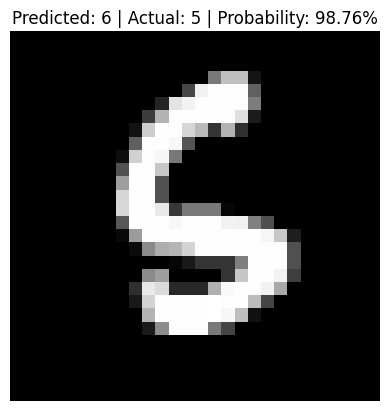

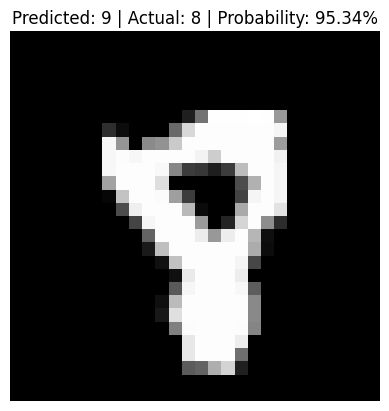

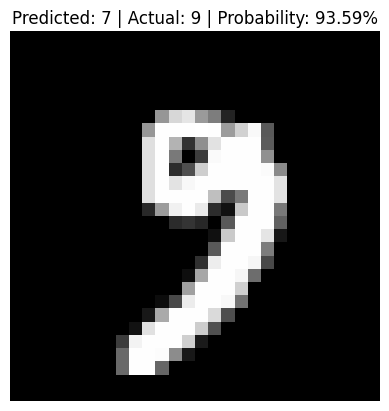

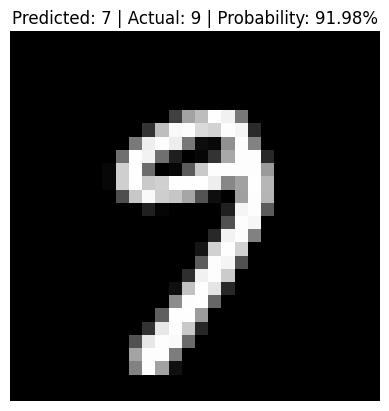

In [11]:
wrong = np.where(dev_predictions != Y_dev)[0]

confidence = np.max(A2_dev, axis=0)

wrong = wrong[np.argsort(confidence[wrong])[::-1]]

for i in wrong[:5]:
    plt.imshow(X_dev[:, i].reshape(28, 28), cmap="gray")
    plt.title(
        f"Predicted: {dev_predictions[i]} | "
        f"Actual: {Y_dev[i]} | "
        f"Probability: {confidence[i]:.2%}"
    )
    plt.axis("off")
    plt.show()